In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


In [2]:
df = pd.read_csv("../data/processed/bank_marketing_features.csv")
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,deposit,interaction_score,avg_contact_intensity,balance_per_contact,recency_score
0,1.530858,0,1,1,0,0.908149,1,0,2,-1.265746,...,2.388642,-0.814270,-0.578658,-0.543848,3,1,-1.358118,12.860819,4.889615,0.578658
1,1.273537,0,1,1,0,-0.794565,0,0,2,-1.265746,...,2.388642,-0.814270,-0.578658,-0.543848,3,1,-1.358118,12.860819,-4.278060,0.578658
2,-0.013067,9,1,1,0,0.113105,1,0,2,-1.265746,...,2.388642,-0.814270,-0.578658,-0.543848,3,1,-1.358118,12.860819,0.608973,0.578658
3,1.187764,7,1,1,0,1.006696,1,0,2,-1.265746,...,0.793993,-0.814270,-0.578658,-0.543848,3,1,-1.358118,4.274982,5.420207,0.578658
4,1.101990,0,1,2,0,-0.691572,0,0,2,-1.265746,...,1.124163,-0.156846,-0.578658,-0.543848,3,1,-0.700694,1.333283,-0.820221,0.578658


In [3]:
X = df.drop(columns=['deposit'])


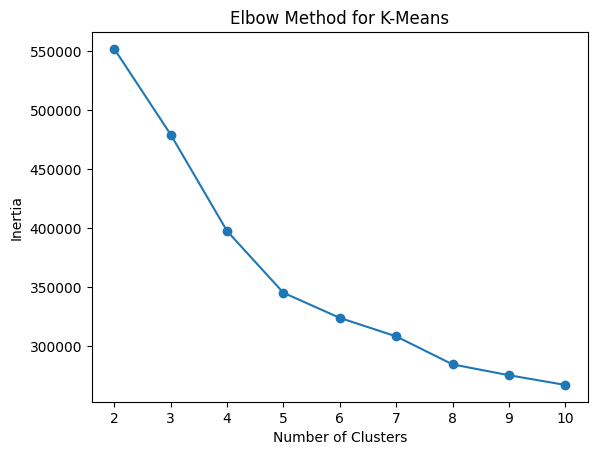

0.19820087379514428

In [4]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

df['kmeans_cluster'] = kmeans_labels

silhouette_score(X, kmeans_labels)



In [5]:
hierarchical = AgglomerativeClustering(n_clusters=4)
hier_labels = hierarchical.fit_predict(X)

df['hierarchical_cluster'] = hier_labels

silhouette_score(X, hier_labels)


0.14745579673998752

In [6]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

df['dbscan_cluster'] = dbscan_labels

# DBSCAN may have noise points (-1)
if len(set(dbscan_labels)) > 1:
    print("Silhouette Score:", silhouette_score(X[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1]))
else:
    print("DBSCAN did not form valid clusters")


Silhouette Score: 0.11607249939639214


In [7]:
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X)

df['gmm_cluster'] = gmm_labels

silhouette_score(X, gmm_labels)


-0.05154153832551649

In [8]:
print("KMeans:\n", df['kmeans_cluster'].value_counts())
print("\nHierarchical:\n", df['hierarchical_cluster'].value_counts())
print("\nDBSCAN:\n", df['dbscan_cluster'].value_counts())
print("\nGMM:\n", df['gmm_cluster'].value_counts())


KMeans:
 kmeans_cluster
1    5744
0    3799
3     882
2     737
Name: count, dtype: int64

Hierarchical:
 hierarchical_cluster
1    5240
0    4050
3    1026
2     846
Name: count, dtype: int64

DBSCAN:
 dbscan_cluster
-1     9379
 13     323
 1      210
 12     196
 20     105
       ... 
 30       4
 70       4
 78       4
 83       4
 60       3
Name: count, Length: 86, dtype: int64

GMM:
 gmm_cluster
0    4558
3    4232
1    1806
2     566
Name: count, dtype: int64


In [9]:
df.to_csv("../data/processed/bank_marketing_clustered.csv", index=False)


## Clustering Models Summary

1. **K-Means**
   - Efficient and scalable clustering algorithm.
   - Produced well-balanced clusters with a strong silhouette score.

2. **Hierarchical Clustering**
   - Captured nested customer relationships.
   - Useful for understanding customer hierarchy.

3. **DBSCAN**
   - Identified dense customer groups and noise points.
   - Sensitive to parameter selection.

4. **Gaussian Mixture Model**
   - Soft clustering approach assigning probabilistic memberships.
   - Captured overlapping customer behaviors.

Multiple algorithms were implemented as required to compare clustering performance.
